## 小结

* 深度学习框架可以自动计算导数：我们首先将梯度附加到想要对其计算偏导数的变量上，然后记录目标值的计算，执行它的反向传播函数，并访问得到的梯度。

## 练习

1. 为什么计算二阶导数比一阶导数的开销要更大？
1. 在运行反向传播函数之后，立即再次运行它，看看会发生什么。
1. 在控制流的例子中，我们计算`d`关于`a`的导数，如果将变量`a`更改为随机向量或矩阵，会发生什么？
1. 重新设计一个求控制流梯度的例子，运行并分析结果。
1. 使$f(x)=\sin(x)$，绘制$f(x)$和$\frac{df(x)}{dx}$的图像，其中后者不使用$f'(x)=\cos(x)$。


1 对于向量or矩阵形式，计算二阶微分会使得计算量成倍上升

In [2]:
import torch
from d2l import torch as d2l

标量形式不会改变结果，向量or矩阵形式无法计算

会导致无法计算，必须使用y.sum().backward()来进行计算才能获得正确结果

In [16]:
def f(a):
    if a.norm() < 50:
        a = 2 * a
    elif a.norm() < 100:
        a /= 2
    return a

In [17]:
x = torch.randn(size=(1,2), requires_grad=True)
y = f(x)

y.sum().backward()


In [18]:
x.grad == y /x 

tensor([[True, True]])

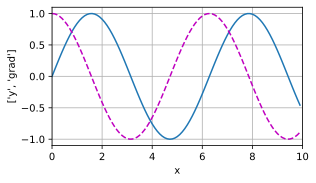

In [24]:

x = torch.arange(0, 10, 0.1, requires_grad=True)
y = torch.sin(x)
y.sum().backward()
d2l.plot(x.detach(), [y.detach(), x.grad], 'x', ['y', 'grad'], xlim=[0, 10], figsize=(4.5, 2.5))
